# Laboratorio 7 — Spark MLlib
## 06. Pipeline de Random Forest

Se busca responder la misma pregunta de la actividad 5 con otro algoritmo: **¿qué tan bien puede estimarse el salario mensual de una persona asalariada con edad, antigüedad, horas semanales, nivel educativo, categoría ocupacional y dominio?**

- Datos: `data/processed/personas_2025.parquet` (población analítica de la sección 1).
- **Mismos conjuntos que la regresión lineal:** entrenamiento 2025 I, II y III; validación 2025 IV. El primer trimestre de 2026 **no se toca** aquí: se reserva para la evaluación final.
- **Misma referencia y mismas métricas:** salario medio de entrenamiento; MAE, RMSE y R² con `RegressionEvaluator`, sobre **todos** los registros de cada conjunto y sin ponderar.
- Todos los componentes del pipeline se ajustan solo con entrenamiento, con semilla fija (`config.SEMILLA`).
- Las asociaciones no son causales, y las estimaciones describen los registros analizados, no a la población guatemalteca.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from src import config, modelado, random_forest, regresion_lineal

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

config.FIGURES.mkdir(parents=True, exist_ok=True)
config.TABLES.mkdir(parents=True, exist_ok=True)
config.MODELOS.mkdir(parents=True, exist_ok=True)

spark = config.crear_spark("lab7_06_random_forest")
spark.sparkContext.setLogLevel("ERROR")

entrenamiento, validacion = modelado.cargar_conjuntos(spark)
entrenamiento, validacion = entrenamiento.persist(), validacion.persist()

tamanos = pd.DataFrame({
    "conjunto": ["entrenamiento (2025 I-III)", "validación (2025 IV)"],
    "registros": [entrenamiento.count(), validacion.count()],
})
tamanos

,conjunto,registros
0,entrenamiento (2025 I-III),40361
1,validación (2025 IV),12664


**Lectura.** Son exactamente los mismos registros de entrenamiento y validación que usó la regresión lineal (`modelado.cargar_conjuntos`), de modo que las diferencias de desempeño se deben al algoritmo y no a los datos.

## 1. Puntos de comparación: referencia y regresión lineal

Para comparar el Random Forest se recalculan aquí, con los mismos conjuntos:

- la **referencia**, que predice para todos el salario medio de entrenamiento (y la mediana, como referencia secundaria);
- la **mejor regresión lineal** de la actividad 5, reajustando sus configuraciones de regularización y eligiendo otra vez la de menor RMSE de validación. La regresión lineal es determinista, así que se obtienen las mismas cifras que en el notebook 05 sin depender de un modelo guardado.

In [2]:
media_ref = modelado.referencia(entrenamiento, "media")
mediana_ref = modelado.referencia(entrenamiento, "mediana")
ref_media = modelado.metricas(modelado.predecir_referencia(validacion, media_ref))
ref_mediana = modelado.metricas(modelado.predecir_referencia(validacion, mediana_ref))

tabla_lineal, modelos_lineales = regresion_lineal.evaluar_configuraciones(entrenamiento, validacion)
mejor_lineal = regresion_lineal.elegir_mejor(tabla_lineal)
modelo_lineal = modelos_lineales[mejor_lineal]
lineal = modelado.metricas(modelo_lineal.transform(validacion))

modelado.tabla_metricas({
    f"referencia: media de entrenamiento (Q{media_ref:,.0f})": ref_media,
    f"referencia: mediana de entrenamiento (Q{mediana_ref:,.0f})": ref_mediana,
    f"regresión lineal ({mejor_lineal})": lineal,
})

,modelo,mae,rmse,r2,n
0,"referencia: media de entrenamiento (Q3,383)","1,672.503","2,889.571",-0.003,"12,664.000"
1,"referencia: mediana de entrenamiento (Q3,000)","1,670.390","2,936.004",-0.036,"12,664.000"
2,regresión lineal (sin_regularizacion),"1,210.137","2,186.420",0.426,"12,664.000"


## 2. Pipeline de Random Forest

| Etapa | Componente | Variables |
|---|---|---|
| a | `StringIndexer` + `OneHotEncoder` | nivel educativo, categoría ocupacional, dominio |
| b | `VectorAssembler` | edad, antigüedad, horas semanales + categóricas codificadas |
| c | `RandomForestRegressor` | `salario_mensual` |

Decisiones:

- Las etapas a y b son **las mismas** que en la regresión lineal (`modelado.etapas_preprocesamiento`): `handleInvalid="keep"` para categorías no vistas en entrenamiento y `DESCONOCIDO` como una categoría más.
- **No se estandariza.** Un árbol divide cada variable por umbrales (`edad <= 35`), y un cambio de escala solo mueve el umbral sin cambiar las divisiones posibles. Por eso el pipeline no tiene `StandardScaler`.
- **Semilla fija** (`seed = config.SEMILLA`): el bosque sortea muestras bootstrap y subconjuntos de variables; con la semilla fija, reejecutar el notebook da el mismo modelo.
- `featureSubsetStrategy = "auto"` (en regresión, un tercio de las columnas en cada división) y `maxBins = 32`, los valores por defecto de Spark. Solo se varían el número de árboles y la profundidad máxima.

In [3]:
etapas = random_forest.pipeline_random_forest(50, 10).getStages()
pd.DataFrame({
    "etapa": range(1, len(etapas) + 1),
    "componente": [type(e).__name__ for e in etapas],
    "entrada": [e.getInputCols() if e.hasParam("inputCols") and e.isSet("inputCols")
                else (e.getInputCol() if e.hasParam("inputCol") and e.isSet("inputCol") else "features")
                for e in etapas],
})

,etapa,componente,entrada
0,1,StringIndexer,nivel_educativo
1,2,StringIndexer,categoria_ocupacional
2,3,StringIndexer,dominio
3,4,OneHotEncoder,"[nivel_educativo_idx, categoria_ocupacional_id..."
4,5,VectorAssembler,"[edad, antiguedad, horas_semanales, nivel_educ..."
5,6,RandomForestRegressor,features


## 3. Configuraciones probadas

- **`numTrees`** (número de árboles): más árboles promedian más predicciones y reducen la varianza del bosque, a cambio de más tiempo de cómputo. No aumenta el sobreajuste.
- **`maxDepth`** (profundidad máxima): árboles más profundos pueden representar interacciones más finas entre variables (por ejemplo, que la antigüedad pese distinto según la educación), pero también memorizar el ruido de entrenamiento.

| Configuración | `numTrees` | `maxDepth` |
|---|---|---|
| `arboles_20_prof_5` | 20 | 5 |
| `arboles_50_prof_5` | 50 | 5 |
| `arboles_50_prof_10` | 50 | 10 |
| `arboles_50_prof_15` | 50 | 15 |
| `arboles_50_prof_20` | 50 | 20 |
| `arboles_100_prof_20` | 100 | 20 |
| `arboles_50_prof_25` | 50 | 25 |

La rejilla compara el número de árboles con la profundidad fija (20 frente a 50 a profundidad 5; 50 frente a 100 a profundidad 20) y la profundidad con 50 árboles fijos (5 a 25). Se extendió hasta 25 para comprobar dónde deja de mejorar la validación y no elegir un extremo arbitrario de la rejilla.

**Criterio de selección:** menor **RMSE de validación**. Cada configuración se ajusta solo con entrenamiento.

In [4]:
tabla, modelos = random_forest.evaluar_configuraciones(entrenamiento, validacion)
mejor = random_forest.elegir_mejor(tabla)

comparacion = tabla.sort_values("rmse_validacion", ignore_index=True)
comparacion.insert(0, "seleccionada", np.where(comparacion["configuracion"] == mejor, "sí", ""))
comparacion

,seleccionada,configuracion,numTrees,maxDepth,mae_entrenamiento,rmse_entrenamiento,r2_entrenamiento,mae_validacion,rmse_validacion,r2_validacion
0,sí,arboles_100_prof_20,100,20,944.596,"1,730.353",0.646,"1,026.695","1,892.526",0.570
1,,arboles_50_prof_25,50,25,935.924,"1,713.399",0.652,"1,025.492","1,893.618",0.569
2,,arboles_50_prof_20,50,20,944.433,"1,720.915",0.649,"1,028.463","1,896.388",0.568
3,,arboles_50_prof_15,50,15,987.708,"1,768.201",0.630,"1,044.004","1,914.230",0.560
4,,arboles_50_prof_10,50,10,"1,071.080","1,923.155",0.562,"1,079.103","1,985.531",0.526
5,,arboles_50_prof_5,50,5,"1,183.513","2,197.534",0.428,"1,163.206","2,160.984",0.439
6,,arboles_20_prof_5,20,5,"1,179.810","2,205.825",0.424,"1,163.162","2,163.872",0.437


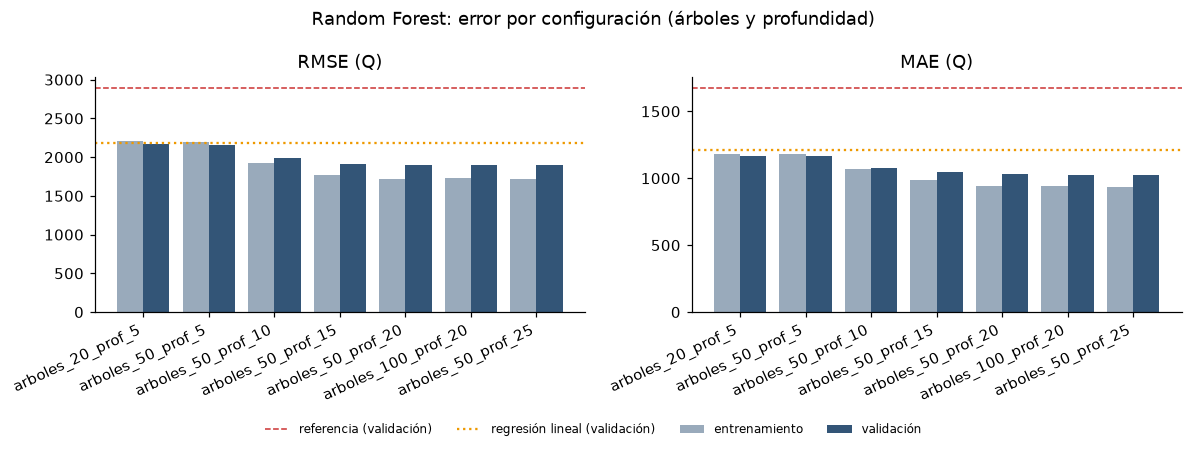

In [5]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8))
orden = list(random_forest.CONFIGURACIONES)
datos = tabla.set_index("configuracion").loc[orden]
pos = np.arange(len(orden))
for eje, metrica, titulo in zip(ejes, ["rmse", "mae"], ["RMSE (Q)", "MAE (Q)"]):
    eje.bar(pos - 0.2, datos[f"{metrica}_entrenamiento"], width=0.4, label="entrenamiento", color="#9ab")
    eje.bar(pos + 0.2, datos[f"{metrica}_validacion"], width=0.4, label="validación", color="#357")
    eje.axhline(ref_media[metrica], color="#c33", ls="--", lw=1, label="referencia (validación)")
    eje.axhline(lineal[metrica], color="#e90", ls=":", lw=1.5, label="regresión lineal (validación)")
    eje.set_xticks(pos, orden, rotation=25, ha="right")
    eje.set_title(titulo)
fig.legend(*ejes[0].get_legend_handles_labels(), loc="upper center", bbox_to_anchor=(0.5, 0.02),
           ncol=4, frameon=False, fontsize=8)
fig.suptitle("Random Forest: error por configuración (árboles y profundidad)")
fig.tight_layout()
fig.savefig(config.FIGURES / "06_error_por_configuracion.png", bbox_inches="tight")
plt.show()

In [6]:
m = tabla.set_index("configuracion").loc[mejor]
por_nombre = tabla.set_index("configuracion")
rmse_v = por_nombre["rmse_validacion"]
brecha = m["rmse_validacion"] / m["rmse_entrenamiento"] - 1
brecha_min = por_nombre.loc["arboles_50_prof_5", "rmse_validacion"] / por_nombre.loc["arboles_50_prof_5", "rmse_entrenamiento"] - 1

display(Markdown(f"""
**Lectura.**

- La configuración con menor RMSE de validación es **`{mejor}`** (`numTrees = {int(m['numTrees'])}`, `maxDepth = {int(m['maxDepth'])}`): RMSE **Q{m['rmse_validacion']:,.0f}**, MAE **Q{m['mae_validacion']:,.0f}** y R² **{m['r2_validacion']:.3f}**.
- **Profundidad.** Con 50 árboles, pasar de profundidad 5 a 10 baja el RMSE de validación de Q{rmse_v['arboles_50_prof_5']:,.0f} a Q{rmse_v['arboles_50_prof_10']:,.0f}, y de 10 a 20 lo baja a Q{rmse_v['arboles_50_prof_20']:,.0f}. De 20 a 25 casi no cambia (Q{rmse_v['arboles_50_prof_25']:,.0f}): la mejora se estanca. La profundidad es el hiperparámetro que más pesa, porque los árboles poco profundos no alcanzan a separar los perfiles con salarios distintos.
- **Número de árboles.** Con la profundidad fija, pasar de 20 a 50 árboles (profundidad 5) cambia el RMSE de validación en {rmse_v['arboles_50_prof_5'] - rmse_v['arboles_20_prof_5']:+,.1f} quetzales, y de 50 a 100 árboles (profundidad 20) en {rmse_v['arboles_100_prof_20'] - rmse_v['arboles_50_prof_20']:+,.1f}: más árboles estabilizan el promedio, pero el efecto es pequeño frente al de la profundidad.
- **Sobreajuste.** En la configuración elegida el RMSE de validación es {100 * brecha:.1f} % mayor que el de entrenamiento; con profundidad 5 los dos errores son casi iguales ({100 * brecha_min:+.1f} %). Al profundizar, el error de entrenamiento baja más rápido que el de validación (la brecha crece), pero el de validación **sigue bajando** hasta estancarse: en esta rejilla no hay un punto en que empeore. El bosque contiene el sobreajuste porque cada árbol se ajusta con una muestra bootstrap y considera solo un tercio de las columnas en cada división, y el promedio de muchos árboles reduce la varianza; además, las numéricas se discretizan en a lo sumo {random_forest.MAX_BINS} intervalos (`maxBins`). Por eso ni el bosque más profundo memoriza entrenamiento (R² de entrenamiento {m['r2_entrenamiento']:.3f}).
"""))


**Lectura.**

- La configuración con menor RMSE de validación es **`arboles_100_prof_20`** (`numTrees = 100`, `maxDepth = 20`): RMSE **Q1,893**, MAE **Q1,027** y R² **0.570**.
- **Profundidad.** Con 50 árboles, pasar de profundidad 5 a 10 baja el RMSE de validación de Q2,161 a Q1,986, y de 10 a 20 lo baja a Q1,896. De 20 a 25 casi no cambia (Q1,894): la mejora se estanca. La profundidad es el hiperparámetro que más pesa, porque los árboles poco profundos no alcanzan a separar los perfiles con salarios distintos.
- **Número de árboles.** Con la profundidad fija, pasar de 20 a 50 árboles (profundidad 5) cambia el RMSE de validación en -2.9 quetzales, y de 50 a 100 árboles (profundidad 20) en -3.9: más árboles estabilizan el promedio, pero el efecto es pequeño frente al de la profundidad.
- **Sobreajuste.** En la configuración elegida el RMSE de validación es 9.4 % mayor que el de entrenamiento; con profundidad 5 los dos errores son casi iguales (-1.7 %). Al profundizar, el error de entrenamiento baja más rápido que el de validación (la brecha crece), pero el de validación **sigue bajando** hasta estancarse: en esta rejilla no hay un punto en que empeore. El bosque contiene el sobreajuste porque cada árbol se ajusta con una muestra bootstrap y considera solo un tercio de las columnas en cada división, y el promedio de muchos árboles reduce la varianza; además, las numéricas se discretizan en a lo sumo 32 intervalos (`maxBins`). Por eso ni el bosque más profundo memoriza entrenamiento (R² de entrenamiento 0.646).


## 4. Comparación en validación: referencia, regresión lineal y Random Forest

Las tres filas se calculan sobre los mismos registros de validación (2025 IV), con las mismas métricas.

In [7]:
bosque = modelado.metricas(modelos[mejor].transform(validacion))
comparacion_validacion = modelado.tabla_metricas({
    "referencia (media de entrenamiento)": ref_media,
    f"regresión lineal ({mejor_lineal})": lineal,
    f"random forest ({mejor})": bosque,
})
comparacion_validacion

,modelo,mae,rmse,r2,n
0,referencia (media de entrenamiento),"1,672.503","2,889.571",-0.003,"12,664.000"
1,regresión lineal (sin_regularizacion),"1,210.137","2,186.420",0.426,"12,664.000"
2,random forest (arboles_100_prof_20),"1,026.695","1,892.526",0.570,"12,664.000"


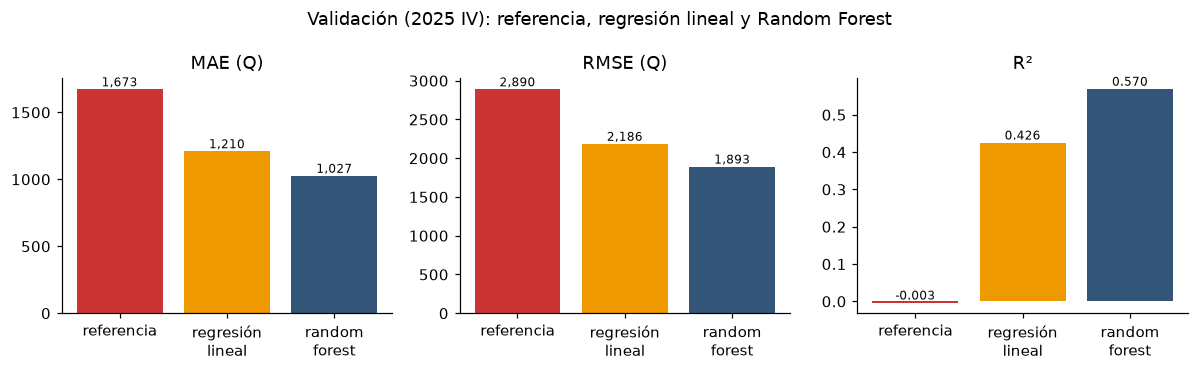

In [8]:
fig, ejes = plt.subplots(1, 3, figsize=(11, 3.4))
colores = ["#c33", "#e90", "#357"]
etiquetas = ["referencia", "regresión\nlineal", "random\nforest"]
for eje, metrica, titulo in zip(ejes, ["mae", "rmse", "r2"], ["MAE (Q)", "RMSE (Q)", "R²"]):
    valores = comparacion_validacion[metrica]
    eje.bar(etiquetas, valores, color=colores)
    for x, v in enumerate(valores):
        eje.annotate(f"{v:,.3f}" if metrica == "r2" else f"{v:,.0f}", (x, v), ha="center", va="bottom", fontsize=8)
    eje.set_title(titulo)
fig.suptitle("Validación (2025 IV): referencia, regresión lineal y Random Forest")
fig.tight_layout()
fig.savefig(config.FIGURES / "06_comparacion_validacion.png", bbox_inches="tight")
plt.show()

In [9]:
def mejora(modelo, ref, metrica):
    return 100 * (1 - modelo[metrica] / ref[metrica])

ganador = "Random Forest" if bosque["rmse"] < lineal["rmse"] else "regresión lineal"
display(Markdown(f"""
**Lectura.**

- Frente a la referencia, la regresión lineal baja el RMSE {mejora(lineal, ref_media, 'rmse'):.1f} % y el Random Forest **{mejora(bosque, ref_media, 'rmse'):.1f} %**; en MAE las reducciones son {mejora(lineal, ref_media, 'mae'):.1f} % y **{mejora(bosque, ref_media, 'mae'):.1f} %**.
- Frente a la regresión lineal, el Random Forest baja el RMSE de validación **{mejora(bosque, lineal, 'rmse'):.1f} %** (Q{lineal['rmse']:,.0f} → Q{bosque['rmse']:,.0f}) y el MAE **{mejora(bosque, lineal, 'mae'):.1f} %** (Q{lineal['mae']:,.0f} → Q{bosque['mae']:,.0f}). El R² sube de {lineal['r2']:.3f} a **{bosque['r2']:.3f}**: los mismos seis predictores explican {100 * bosque['r2']:.1f} % de la variación del salario en validación, frente a {100 * lineal['r2']:.1f} % con la regresión.
- **En validación, el mejor algoritmo es el {ganador}**, en las tres métricas.
- Aun así, un error típico (MAE) de Q{bosque['mae']:,.0f} es grande frente a un salario mediano de Q{mediana_ref:,.0f}: con seis predictores queda mucha variación salarial sin explicar (ocupación concreta, rama de actividad, empresa, región fina, etc.).
"""))


**Lectura.**

- Frente a la referencia, la regresión lineal baja el RMSE 24.3 % y el Random Forest **34.5 %**; en MAE las reducciones son 27.6 % y **38.6 %**.
- Frente a la regresión lineal, el Random Forest baja el RMSE de validación **13.4 %** (Q2,186 → Q1,893) y el MAE **15.2 %** (Q1,210 → Q1,027). El R² sube de 0.426 a **0.570**: los mismos seis predictores explican 57.0 % de la variación del salario en validación, frente a 42.6 % con la regresión.
- **En validación, el mejor algoritmo es el Random Forest**, en las tres métricas.
- Aun así, un error típico (MAE) de Q1,027 es grande frente a un salario mediano de Q3,000: con seis predictores queda mucha variación salarial sin explicar (ocupación concreta, rama de actividad, empresa, región fina, etc.).


## 5. Importancia de variables

`featureImportances` mide cuánto reduce cada columna la varianza del salario en las divisiones de todos los árboles, normalizado para que sume 1. Se presenta por columna del vector (cada categoría one-hot por separado) y **sumada por predictor**, que es la lectura comparable entre las seis variables.

Es una medida del uso que el bosque hace de cada variable, no un efecto causal ni un signo (a diferencia de los coeficientes lineales, no dice si la variable sube o baja el salario). Además tiende a favorecer a las variables continuas, que ofrecen más umbrales posibles.

In [10]:
imp = random_forest.importancias(modelos[mejor])
imp_predictor = random_forest.importancias_por_predictor(imp)
display(imp_predictor)
imp.head(12)

,predictor,importancia
0,nivel_educativo,0.343
1,categoria_ocupacional,0.259
2,horas_semanales,0.124
3,edad,0.122
4,antiguedad,0.110
5,dominio,0.042


,variable,importancia
0,nivel_educativo=6,0.157
1,horas_semanales,0.124
2,edad,0.122
3,nivel_educativo=5,0.115
4,antiguedad,0.110
5,categoria_ocupacional=1,0.099
6,categoria_ocupacional=2,0.065
7,categoria_ocupacional=3,0.064
8,categoria_ocupacional=4,0.031
9,dominio=1,0.029


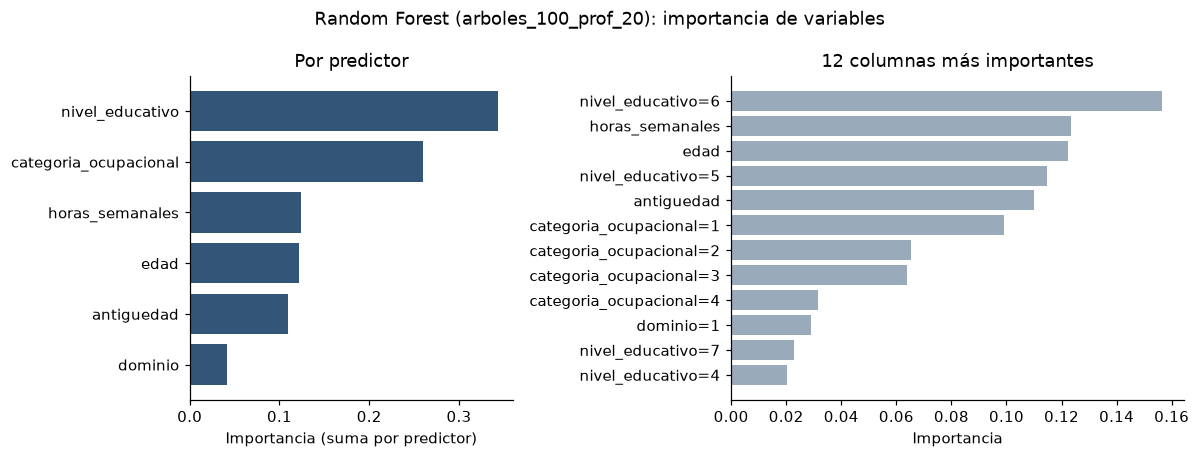

In [11]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1, 1.4]})
ip = imp_predictor.iloc[::-1]
ejes[0].barh(ip["predictor"], ip["importancia"], color="#357")
ejes[0].set_xlabel("Importancia (suma por predictor)")
ejes[0].set_title("Por predictor")
top = imp.head(12).iloc[::-1]
ejes[1].barh(top["variable"], top["importancia"], color="#9ab")
ejes[1].set_xlabel("Importancia")
ejes[1].set_title("12 columnas más importantes")
fig.suptitle(f"Random Forest ({mejor}): importancia de variables")
fig.tight_layout()
fig.savefig(config.FIGURES / "06_importancias.png", bbox_inches="tight")
plt.show()

In [12]:
peso = imp_predictor.set_index("predictor")["importancia"]
categoricas = peso[config.CATEGORICAS].sum()
coef_lineal = regresion_lineal.coeficientes(modelo_lineal)
top_lineal = coef_lineal[coef_lineal["variable"] != "(intercepto)"].iloc[0]

display(Markdown(f"""
**Lectura.**

- El predictor más usado por el bosque es **`{imp_predictor.iloc[0]['predictor']}`** ({100 * imp_predictor.iloc[0]['importancia']:.1f} % de la importancia), seguido de `{imp_predictor.iloc[1]['predictor']}` ({100 * imp_predictor.iloc[1]['importancia']:.1f} %). Las columnas individuales más importantes son `{imp.iloc[0]['variable']}` y `{imp.iloc[1]['variable']}`.
- Las tres categóricas suman {100 * categoricas:.1f} % y las tres numéricas {100 * (1 - categoricas):.1f} %. Edad, antigüedad y horas pesan {100 * peso['edad']:.1f} %, {100 * peso['antiguedad']:.1f} % y {100 * peso['horas_semanales']:.1f} %; `dominio` es el que menos aporta ({100 * peso['dominio']:.1f} %).
- La lectura coincide con la regresión lineal, cuyo coeficiente de mayor magnitud también es de nivel educativo (`{top_lineal['variable']}`, Q{top_lineal['coeficiente']:,.0f}): en ambos modelos la educación es lo que más distingue salarios.
- Las numéricas suman {100 * (1 - categoricas):.1f} % aunque en la regresión su efecto lineal es moderado (unos Q20 por año u hora). En parte se debe a que ofrecen muchos umbrales posibles, y en parte a que el bosque las usa de forma no lineal y en combinación con las categóricas, que es justamente lo que la regresión no puede hacer.
"""))


**Lectura.**

- El predictor más usado por el bosque es **`nivel_educativo`** (34.3 % de la importancia), seguido de `categoria_ocupacional` (25.9 %). Las columnas individuales más importantes son `nivel_educativo=6` y `horas_semanales`.
- Las tres categóricas suman 64.4 % y las tres numéricas 35.6 %. Edad, antigüedad y horas pesan 12.2 %, 11.0 % y 12.4 %; `dominio` es el que menos aporta (4.2 %).
- La lectura coincide con la regresión lineal, cuyo coeficiente de mayor magnitud también es de nivel educativo (`nivel_educativo=7`, Q8,702): en ambos modelos la educación es lo que más distingue salarios.
- Las numéricas suman 35.6 % aunque en la regresión su efecto lineal es moderado (unos Q20 por año u hora). En parte se debe a que ofrecen muchos umbrales posibles, y en parte a que el bosque las usa de forma no lineal y en combinación con las categóricas, que es justamente lo que la regresión no puede hacer.


## 6. ¿Por qué difieren? Error por tramo de salario en validación

Diferencias entre los dos algoritmos que pueden explicar su desempeño:

- **Forma de la relación.** La regresión lineal supone que cada variable suma un monto fijo, igual para todos. El Random Forest divide a las personas en grupos por umbrales y promedia su salario, por lo que puede capturar **no linealidades** (que la edad suba el salario hasta cierto punto y luego no) e **interacciones** (que la antigüedad o las horas paguen distinto según la educación o la categoría ocupacional) sin especificarlas.
- **Extrapolación.** El bosque predice promedios de salarios de entrenamiento, por lo que nunca predice fuera del rango observado y tiende a **encoger** los extremos hacia el centro. La regresión sí puede extrapolar linealmente, pero también estima un único efecto medio.
- **Salarios extremos.** Ninguno de los dos recorta la cola de salarios altos; ambos minimizan el error cuadrático y se ven arrastrados por ella.

Para ver dónde se gana y dónde se pierde, se agrupan los registros de validación en cinco tramos según su **salario real** (cortes en los percentiles 20, 40, 60 y 80 de validación) y se calcula el MAE y el error medio (residuo = real − predicho) de cada modelo en cada tramo, con **todos** los registros de validación. Un error medio positivo indica subestimación y uno negativo, sobreestimación. El análisis completo de errores sobre 2026 corresponde a la actividad 8.

In [13]:
cortes = random_forest.cortes_tramos(validacion)
tramos = pd.concat([
    random_forest.error_por_tramo(modelo_lineal.transform(validacion), cortes).assign(modelo="regresión lineal"),
    random_forest.error_por_tramo(modelos[mejor].transform(validacion), cortes).assign(modelo="random forest"),
], ignore_index=True)
tramos.pivot(index=["tramo", "rango", "n", "salario_real_medio"], columns="modelo",
             values=["prediccion_media", "mae", "error_medio"])

prediccion_media                            mae                    error_medio                 
modelo                                           random forest regresión lineal random forest regresión lineal random forest regresión lineal
tramo rango           n    salario_real_medio                                                                                                
0     <= Q1,600       2606 1,040.364                 1,711.954        1,870.419       746.320          961.395      -671.590         -830.056
1     Q1,600 - Q2,800 2676 2,245.655                 2,598.166        2,653.606       693.147          881.593      -352.511         -407.952
2     Q2,800 - Q3,600 2600 3,288.567                 3,385.942        3,406.672       692.514          820.448       -97.375         -118.105
3     Q3,600 - Q4,400 2261 3,926.996                 3,990.863        4,026.267       712.438          809.778       -63.867          -99.271
4     > Q4,400        2521 7,433.053                 5,715.261        5,371.047     2,297.078        2,576.981     1,717.791        2,062.006

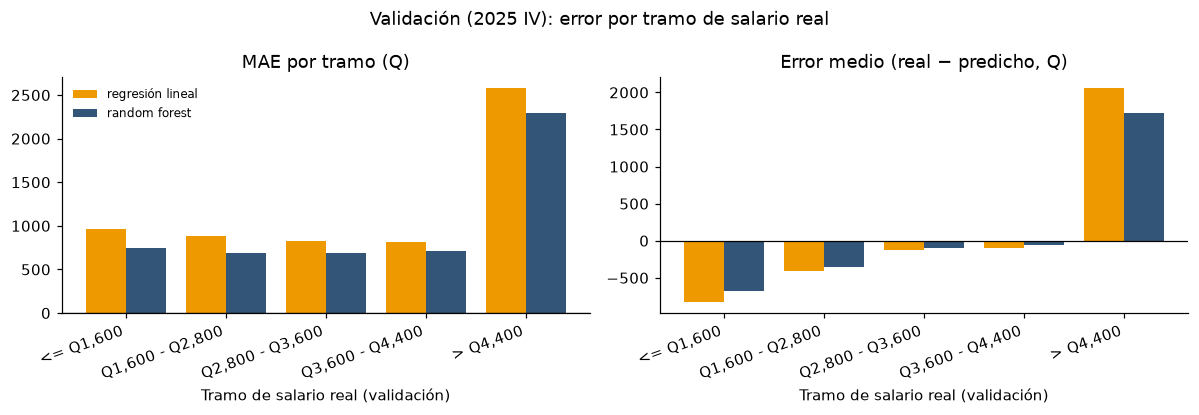

In [14]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8))
rangos = tramos.loc[tramos["modelo"] == "random forest", "rango"].tolist()
pos = np.arange(len(rangos))
for eje, metrica, titulo in zip(ejes, ["mae", "error_medio"], ["MAE por tramo (Q)", "Error medio (real − predicho, Q)"]):
    for desplazamiento, (nombre, color) in zip([-0.2, 0.2], [("regresión lineal", "#e90"), ("random forest", "#357")]):
        valores = tramos.loc[tramos["modelo"] == nombre, metrica]
        eje.bar(pos + desplazamiento, valores, width=0.4, label=nombre, color=color)
    eje.axhline(0, color="k", lw=0.8)
    eje.set_xticks(pos, rangos, rotation=20, ha="right")
    eje.set_xlabel("Tramo de salario real (validación)")
    eje.set_title(titulo)
ejes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Validación (2025 IV): error por tramo de salario real")
fig.tight_layout()
fig.savefig(config.FIGURES / "06_error_por_tramo.png", bbox_inches="tight")
plt.show()

In [15]:
t = tramos.set_index(["modelo", "tramo"])
ultimo = len(cortes)
rf_alto, rl_alto = t.loc[("random forest", ultimo)], t.loc[("regresión lineal", ultimo)]
rf_bajo, rl_bajo = t.loc[("random forest", 0)], t.loc[("regresión lineal", 0)]
ganancia = t.loc["regresión lineal", "mae"] - t.loc["random forest", "mae"]
tramos_rf_gana = int((ganancia > 0).sum())
q = lambda v: f"-Q{abs(v):,.0f}" if v < 0 else f"Q{v:,.0f}"

display(Markdown(f"""
**Lectura.**

- El Random Forest tiene menor MAE que la regresión en **{tramos_rf_gana} de {ultimo + 1}** tramos de salario.
- **Salarios bajos** ({rf_bajo['rango']}, salario real medio Q{rf_bajo['salario_real_medio']:,.0f}): ambos modelos **sobreestiman** (error medio {q(rl_bajo['error_medio'])} la regresión y {q(rf_bajo['error_medio'])} el bosque).
- **Salarios altos** ({rf_alto['rango']}, salario real medio Q{rf_alto['salario_real_medio']:,.0f}): ambos **subestiman** (error medio Q{rl_alto['error_medio']:,.0f} la regresión y Q{rf_alto['error_medio']:,.0f} el bosque) y es el tramo con el MAE más alto (Q{rl_alto['mae']:,.0f} y Q{rf_alto['mae']:,.0f}). Es el patrón de **regresión hacia la media**: con predictores que explican solo parte de la variación, las predicciones se concentran cerca del centro y los extremos se acercan a él.
- La reducción del MAE es mayor en los extremos (Q{ganancia.loc[0]:,.0f} en el tramo más bajo y Q{ganancia.loc[ultimo]:,.0f} en el más alto) que en el centro (Q{ganancia.loc[ultimo // 2]:,.0f}): al combinar variables, el bosque se acerca más a los perfiles de salario bajo y alto, aunque sigue lejos de ellos, en lugar de sumar efectos promedio.
"""))


**Lectura.**

- El Random Forest tiene menor MAE que la regresión en **5 de 5** tramos de salario.
- **Salarios bajos** (<= Q1,600, salario real medio Q1,040): ambos modelos **sobreestiman** (error medio -Q830 la regresión y -Q672 el bosque).
- **Salarios altos** (> Q4,400, salario real medio Q7,433): ambos **subestiman** (error medio Q2,062 la regresión y Q1,718 el bosque) y es el tramo con el MAE más alto (Q2,577 y Q2,297). Es el patrón de **regresión hacia la media**: con predictores que explican solo parte de la variación, las predicciones se concentran cerca del centro y los extremos se acercan a él.
- La reducción del MAE es mayor en los extremos (Q215 en el tramo más bajo y Q280 en el más alto) que en el centro (Q128): al combinar variables, el bosque se acerca más a los perfiles de salario bajo y alto, aunque sigue lejos de ellos, en lugar de sumar efectos promedio.


## 7. ¿Cuál algoritmo fue mejor en validación?

In [16]:
display(Markdown(f"""
En validación (2025 IV) el **{ganador}** obtuvo mejores resultados en MAE, RMSE y R² (RMSE Q{bosque['rmse']:,.0f} frente a Q{lineal['rmse']:,.0f}; R² {bosque['r2']:.3f} frente a {lineal['r2']:.3f}). Las diferencias que pueden explicarlo:

1. **No linealidad e interacciones.** Con las mismas seis variables, el bosque puede representar que el efecto de la edad, la antigüedad o las horas cambie según el nivel educativo o la categoría ocupacional. La regresión solo estima un efecto promedio aditivo por variable; su regularización casi no cambió el resultado, lo que indica que su límite no es el sobreajuste sino la forma del modelo.
2. **Profundidad suficiente.** La ganancia aparece cuando los árboles son lo bastante profundos para separar esos perfiles: con profundidad 5 el bosque apenas supera a la regresión (RMSE Q{rmse_v['arboles_50_prof_5']:,.0f} frente a Q{lineal['rmse']:,.0f}).
3. **Sobreajuste contenido.** Árboles tan profundos sobreajustarían por separado, pero el bosque promedia muchos árboles entrenados con muestras bootstrap y subconjuntos de columnas, lo que reduce la varianza; la brecha entre entrenamiento y validación ({100 * brecha:.1f} % en RMSE) es moderada.

Límites comunes a los dos modelos: ambos subestiman los salarios altos y sobreestiman los bajos, y dejan sin explicar alrededor de {100 * (1 - bosque['r2']):.0f} % de la variación del salario. El bosque, además, es menos interpretable (importancias sin signo en lugar de coeficientes en quetzales) y no extrapola fuera del rango de entrenamiento. La comparación definitiva se hace en la actividad 7, sobre el primer trimestre de 2026.
"""))


En validación (2025 IV) el **Random Forest** obtuvo mejores resultados en MAE, RMSE y R² (RMSE Q1,893 frente a Q2,186; R² 0.570 frente a 0.426). Las diferencias que pueden explicarlo:

1. **No linealidad e interacciones.** Con las mismas seis variables, el bosque puede representar que el efecto de la edad, la antigüedad o las horas cambie según el nivel educativo o la categoría ocupacional. La regresión solo estima un efecto promedio aditivo por variable; su regularización casi no cambió el resultado, lo que indica que su límite no es el sobreajuste sino la forma del modelo.
2. **Profundidad suficiente.** La ganancia aparece cuando los árboles son lo bastante profundos para separar esos perfiles: con profundidad 5 el bosque apenas supera a la regresión (RMSE Q2,161 frente a Q2,186).
3. **Sobreajuste contenido.** Árboles tan profundos sobreajustarían por separado, pero el bosque promedia muchos árboles entrenados con muestras bootstrap y subconjuntos de columnas, lo que reduce la varianza; la brecha entre entrenamiento y validación (9.4 % en RMSE) es moderada.

Límites comunes a los dos modelos: ambos subestiman los salarios altos y sobreestiman los bajos, y dejan sin explicar alrededor de 43 % de la variación del salario. El bosque, además, es menos interpretable (importancias sin signo en lugar de coeficientes en quetzales) y no extrapola fuera del rango de entrenamiento. La comparación definitiva se hace en la actividad 7, sobre el primer trimestre de 2026.


## 8. Guardado del mejor modelo

Se guarda el pipeline ajustado con la configuración seleccionada en `results/modelos/random_forest` (no se versiona) y las tablas en `results/tables/`. El primer trimestre de 2026 se reserva para la evaluación final. Para esa evaluación se reajustará la configuración elegida (`random_forest.pipeline_random_forest` con los mismos `numTrees` y `maxDepth` y la misma semilla) con los cuatro trimestres de 2025.

In [17]:
random_forest.guardar_resultados(tabla, mejor, modelos[mejor], imp, comparacion_validacion, tramos)
print(f"Modelo guardado en {config.MODELOS / 'random_forest'}")
print("Tablas:", sorted(p.name for p in config.TABLES.glob("06_*.csv")))
print("Figuras:", sorted(p.name for p in config.FIGURES.glob("06_*.png")))

Modelo guardado en /Users/joel/Desktop/Lab7_Data/Laboratorio-7-Introduccion-a-Spark/results/modelos/random_forest
Tablas: ['06_comparacion_validacion.csv', '06_error_por_tramo_validacion.csv', '06_importancias_random_forest.csv', '06_metricas_random_forest.csv']
Figuras: ['06_comparacion_validacion.png', '06_error_por_configuracion.png', '06_error_por_tramo.png', '06_importancias.png']


## 9. Conclusión de la actividad

El Random Forest usa los mismos conjuntos, preprocesamiento categórico, referencia y métricas que la regresión lineal, con semilla fija y todas sus etapas ajustadas solo con entrenamiento. Se probaron siete combinaciones de número de árboles y profundidad máxima y se eligió la de menor RMSE de validación. La profundidad es lo que más mejora el desempeño, y el bosque supera a la regresión lineal porque puede combinar las variables en lugar de sumar efectos fijos. Ambos modelos comparten la tendencia a subestimar los salarios altos. La configuración elegida de cada algoritmo pasa a la actividad 7, donde se reentrenan con los cuatro trimestres de 2025 y se evalúan sobre los mismos registros del primer trimestre de 2026.